In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtb
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\ML_PROJECT\Exam_Score_Prediction.csv')

In [3]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,200.99,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,200.99,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,200.99,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,200.99,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [4]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.500000,20.473300,4.007604,70.017365,7.00856,62.513225
std,5770.211372,2.284458,2.308313,17.282262,1.73209,18.908491
min,200.990000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,19800.010000,24.000000,7.910000,99.400000,9.90000,100.000000


In [5]:
Q1=df.exam_score.quantile(0.25)
Q3=df.exam_score.quantile(0.75)
Q1,Q3

(np.float64(48.8), np.float64(76.3))

In [6]:
IQR=Q3-Q1
IQR

np.float64(27.5)

In [7]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit


(np.float64(7.549999999999997), np.float64(117.55))

In [8]:
df[(df.exam_score<lower_limit)|(df.exam_score>upper_limit)]

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score


In [9]:
df.isnull().sum().sum()

np.int64(0)

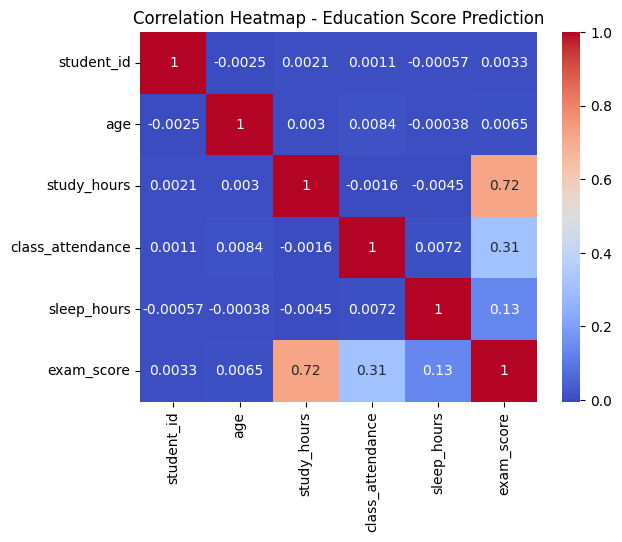

In [23]:

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
mtb.title("Correlation Heatmap - Education Score Prediction")
mtb.show()

<Axes: xlabel='study_hours', ylabel='exam_score'>

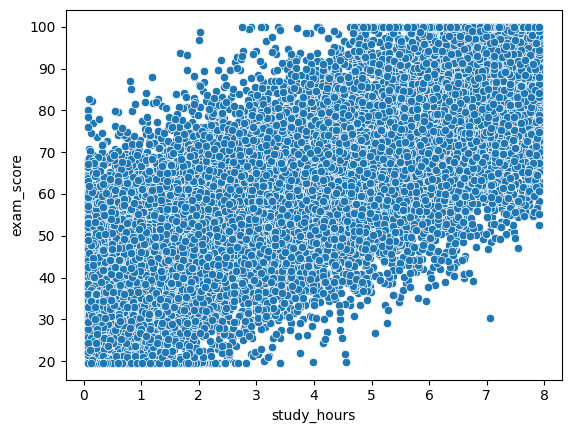

In [21]:
sns.scatterplot(x='study_hours',y='exam_score',data=df)



In [12]:
df.tail(1)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
19999,19800.01,20,male,b.sc,7.5,47.9,yes,7.5,poor,coaching,medium,moderate,71.0


<Axes: ylabel='exam_score'>

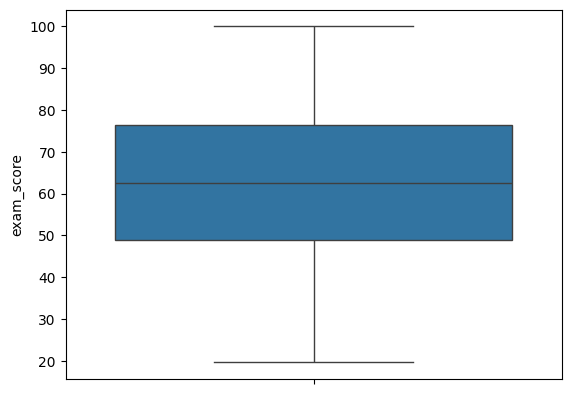

In [13]:
sns.boxplot(y=df['exam_score'])



(array([859., 301., 313., 340., 334., 317., 662., 334., 315., 349., 357.,
        300., 684., 320., 332., 362., 320., 354., 684., 359., 311., 321.,
        345., 306., 321., 662., 327., 362., 351., 335., 328., 669., 336.,
        304., 318., 312., 326., 623., 360., 343., 336., 341., 339., 701.,
        329., 329., 336., 340., 359., 834.]),
 array([4.1  , 4.216, 4.332, 4.448, 4.564, 4.68 , 4.796, 4.912, 5.028,
        5.144, 5.26 , 5.376, 5.492, 5.608, 5.724, 5.84 , 5.956, 6.072,
        6.188, 6.304, 6.42 , 6.536, 6.652, 6.768, 6.884, 7.   , 7.116,
        7.232, 7.348, 7.464, 7.58 , 7.696, 7.812, 7.928, 8.044, 8.16 ,
        8.276, 8.392, 8.508, 8.624, 8.74 , 8.856, 8.972, 9.088, 9.204,
        9.32 , 9.436, 9.552, 9.668, 9.784, 9.9  ]),
 <BarContainer object of 50 artists>)

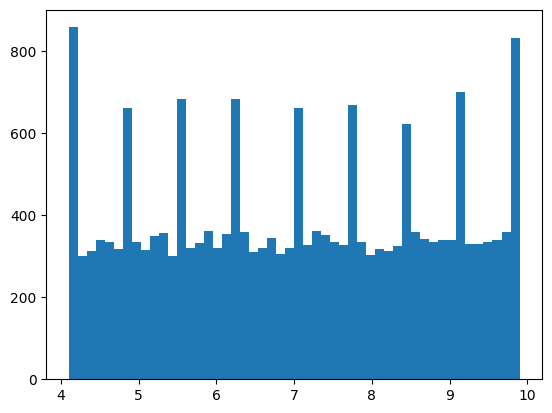

In [14]:
mtb.hist(df['sleep_hours'],bins=50)



(array([2514.,    0., 2542.,    0.,    0., 2528.,    0.,    0., 2488.,
           0.,    0., 2555.,    0.,    0., 2497.,    0.,    0., 2433.,
           0., 2443.]),
 array([17.  , 17.35, 17.7 , 18.05, 18.4 , 18.75, 19.1 , 19.45, 19.8 ,
        20.15, 20.5 , 20.85, 21.2 , 21.55, 21.9 , 22.25, 22.6 , 22.95,
        23.3 , 23.65, 24.  ]),
 <BarContainer object of 20 artists>)

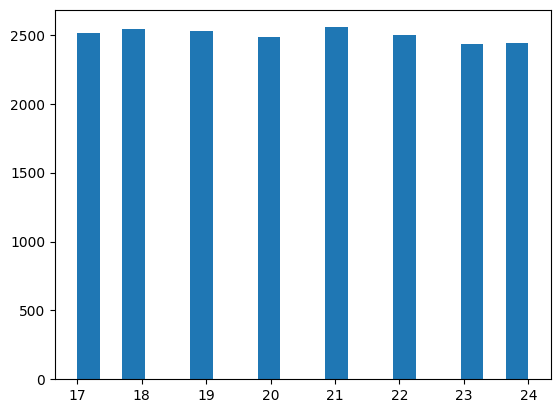

In [15]:
mtb.hist(df['age'],bins=20)


(array([ 657., 1014., 1821., 2485., 2892., 3106., 2881., 2292., 1551.,
        1301.]),
 array([ 19.599 ,  27.6391,  35.6792,  43.7193,  51.7594,  59.7995,
         67.8396,  75.8797,  83.9198,  91.9599, 100.    ]),
 <BarContainer object of 10 artists>)

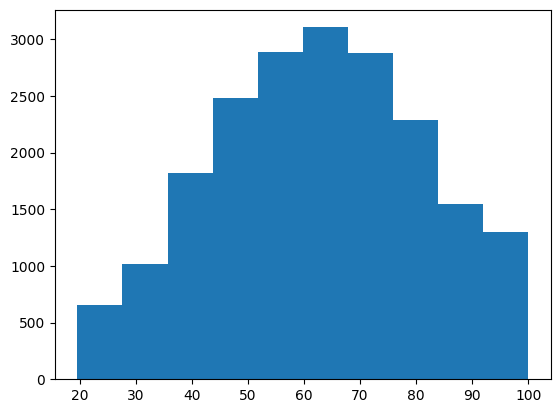

In [16]:
mtb.hist(df['exam_score'])


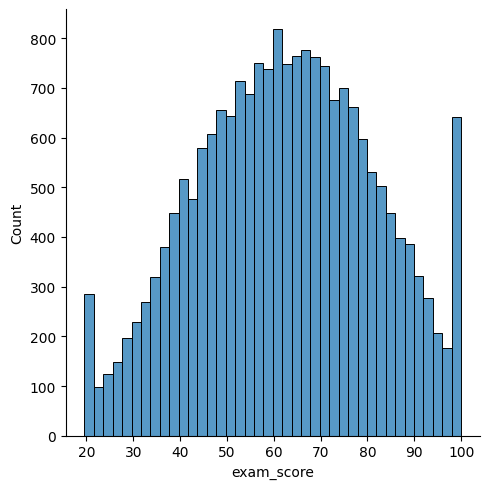

In [17]:
sns.displot(df['exam_score'])


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [19]:
df.head(1)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9


In [ ]:
df


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [32]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


In [33]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [34]:
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [35]:
X = df_encoded.drop("exam_score", axis=1)
y = df_encoded["exam_score"]


In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


In [39]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
y_pred = model.predict(X_test)

In [41]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [42]:
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance (Coefficients):")
print(coeff)



Feature Importance (Coefficients):
                       Feature  Coefficient
1                  study_hours    13.571418
2             class_attendance     5.957087
3                  sleep_hours     2.487898
13          sleep_quality_good     2.138041
22    exam_difficulty_moderate     0.115057
5                 gender_other     0.094027
7                course_b.tech     0.057654
21        exam_difficulty_hard     0.045580
10                  course_bca     0.039444
8                    course_ba     0.033177
12         internet_access_yes     0.028779
4                  gender_male     0.021973
11              course_diploma     0.019350
9                   course_bba    -0.001467
0                          age    -0.018568
6                  course_b.sc    -0.073137
20      facility_rating_medium    -1.798309
16          study_method_mixed    -1.969532
14          sleep_quality_poor    -2.259618
15    study_method_group study    -3.087505
17  study_method_online videos    -3.570